In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, GreedyAgent
from ant.decentralised.neighbours import RecirpocateAgent, MaxFinder
from ant.decentralised.dynamic import COAPAgent
from ant.centralised import P4
from ant.decentralised.utility import create_grid_graph

In [2]:
market_seed = 21234
graph_seed = 1
market_size = 80
cavement_div = 5
ks = [
    1,
    2,
    3,
    4,
    5,
    6,
    7
]

graphs = {
    "Fully Connected": nx.complete_graph(market_size),
    "Random": nx.gnp_random_graph(market_size, 0.05, seed=graph_seed),
    "Grid": create_grid_graph(market_size),
    "Small-World": nx.watts_strogatz_graph(market_size, int(market_size / 2), 0.05, seed=graph_seed),
    ### Other graphs experiments could be ran on ###
    # "Small World": nx.watts_strogatz_graph(market_size, int(market_size / 2), 0.05, seed=graph_seed)
    # "Ladder": nx.circular_ladder_graph(int(market_size / 2)),
    # "Scale-free": nx.barabasi_albert_graph(market_size, 1, seed=graph_seed),
    # "Caveman": nx.connected_caveman_graph(int(market_size / cavement_div), cavement_div)
}

markets = {}

for graph_type in graphs.keys():
    markets[graph_type] = []
    for optimizer_k in ks:
        print(f"Creating {graph_type}, k={optimizer_k}")
        _market = Market(
            market_size,
            graph=graphs[graph_type],
            seed=market_seed,
            agent_type=COAPAgent,
            resource_volatility=0.01,
            k=optimizer_k,
            report_crashes=False,
        )
        markets[graph_type].append(
            {
                "agent_strategy": "COAP",
                "k": optimizer_k,
                "graph_type": graph_type,
                "market": _market,
                "optimal_allocations": None,
                "utility_vector": None,
                "simulation_result": None,
                # "avg_market_ratio": np.mean(
                #     np.array([agent.submarket.market_ratio for agent in _market.agents])
                # ),
                # "max_market_ratio": np.max(
                #     np.array([agent.submarket.market_ratio for agent in _market.agents])
                # ),
            }
        )
    # benchmark
    markets[graph_type].append(
        {
            "agent_strategy": "Proportional",
            "k": None,
            "market": Market(
                market_size,
                graph=graphs[graph_type],
                seed=market_seed,
                agent_type=ProportionalAgent,
            ),
            "optimal_allocations": None,
            "utility_vector": None,
            "simulation_result": None,
            "avg_market_ratio": None,
            "max_market_ratio": None,
        }
    )
    ### The greedy agent could also be compared against ###
    # markets[graph_type].append(
    #     {
    #         "agent_strategy": "Greedy",
    #         "k": None,
    #         "market": Market(
    #             market_size,
    #             graph=graphs[graph_type],
    #             seed=market_seed,
    #             agent_type=GreedyAgent,
    #         ),
    #         "optimal_allocations": None,
    #         "utility_vector": None,
    #         "simulation_result": None,
    #         "avg_market_ratio": None,
    #         "max_market_ratio": None,
    #     }
    # )

Creating Fully Connected, k=1
Creating Fully Connected, k=2
Creating Fully Connected, k=3
Creating Fully Connected, k=4
Creating Fully Connected, k=5
Creating Fully Connected, k=6
Creating Fully Connected, k=7
Creating Random, k=1
Creating Random, k=2
Creating Random, k=3
Creating Random, k=4
Creating Random, k=5
Creating Random, k=6
Creating Random, k=7
Creating Grid, k=1
Creating Grid, k=2
Creating Grid, k=3
Creating Grid, k=4
Creating Grid, k=5
Creating Grid, k=6
Creating Grid, k=7
Creating Small-World, k=1
Creating Small-World, k=2
Creating Small-World, k=3
Creating Small-World, k=4
Creating Small-World, k=5
Creating Small-World, k=6
Creating Small-World, k=7


In [3]:
for graph_type in markets.keys():
    for entry in markets[graph_type]:
        entry["optimal_allocations"], entry["utility_vector"] = P4(entry["market"])
        entry["market"].set_market_equilibrium(entry["optimal_allocations"], entry["utility_vector"])

/home/joeri/Projects/RP/Ant/src/ant/centralised.py:50: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  result = prob.solve()


In [4]:
simulation_duration = 50
for graph_type in markets.keys():
    for entry in markets[graph_type]:
        entry["simulation_result"] = entry["market"].simulate(simulation_duration, use_average_in_market_loss=True, return_utility_instead_of_market_loss=False)
        if entry["agent_strategy"] == "COAP" or entry["agent_strategy"] == "Bad COAP":
            health = sum([1 if not agent.has_crashed else 0 for agent in entry["market"].agents]) / len(entry["market"])
            print(f"{graph_type} {entry['agent_strategy']}, k={entry['k']} health: {int(health*100)}%")
        else:
            print(f"{graph_type}, " + entry["agent_strategy"])

Fully Connected COAP, k=1 health: 100%
Fully Connected COAP, k=2 health: 100%
Fully Connected COAP, k=3 health: 100%
Fully Connected COAP, k=4 health: 100%
Fully Connected COAP, k=5 health: 100%
Fully Connected COAP, k=6 health: 100%
Fully Connected COAP, k=7 health: 100%
Fully Connected, Proportional
Random COAP, k=1 health: 100%
Random COAP, k=2 health: 100%


/home/joeri/Projects/RP/Ant/src/ant/decentralised/utility.py:90: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  result = prob.solve()


Random COAP, k=3 health: 100%
Random COAP, k=4 health: 100%
Random COAP, k=5 health: 100%
Random COAP, k=6 health: 100%
Random COAP, k=7 health: 100%
Random, Proportional
Grid COAP, k=1 health: 100%
Grid COAP, k=2 health: 100%
Grid COAP, k=3 health: 100%
Grid COAP, k=4 health: 100%
Grid COAP, k=5 health: 100%
Grid COAP, k=6 health: 100%
Grid COAP, k=7 health: 100%
Grid, Proportional
Small-World COAP, k=1 health: 100%
Small-World COAP, k=2 health: 100%
Small-World COAP, k=3 health: 100%
Small-World COAP, k=4 health: 100%
Small-World COAP, k=5 health: 100%
Small-World COAP, k=6 health: 100%
Small-World COAP, k=7 health: 100%
Small-World, Proportional


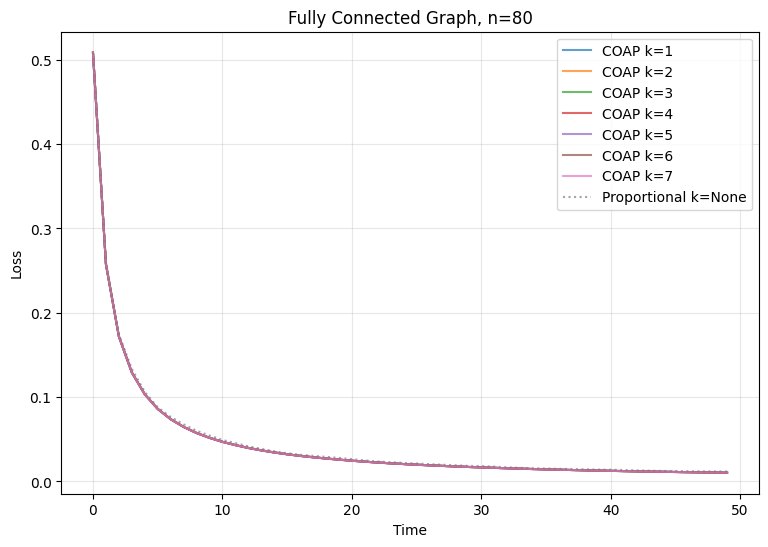

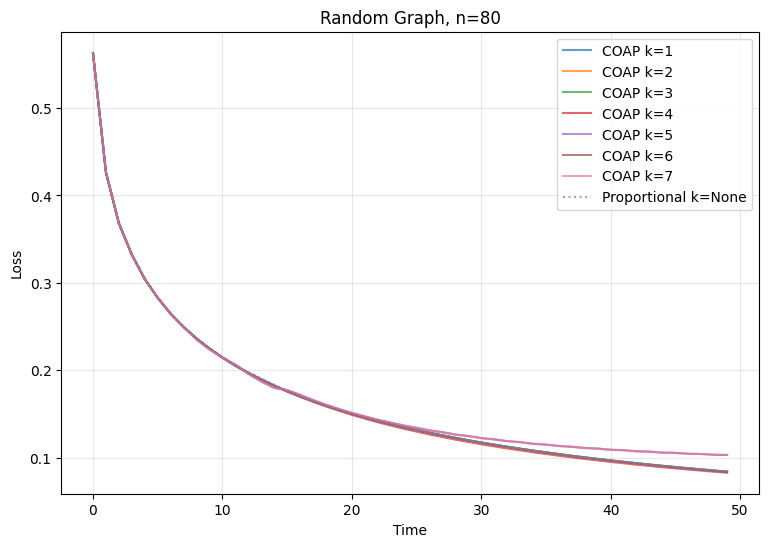

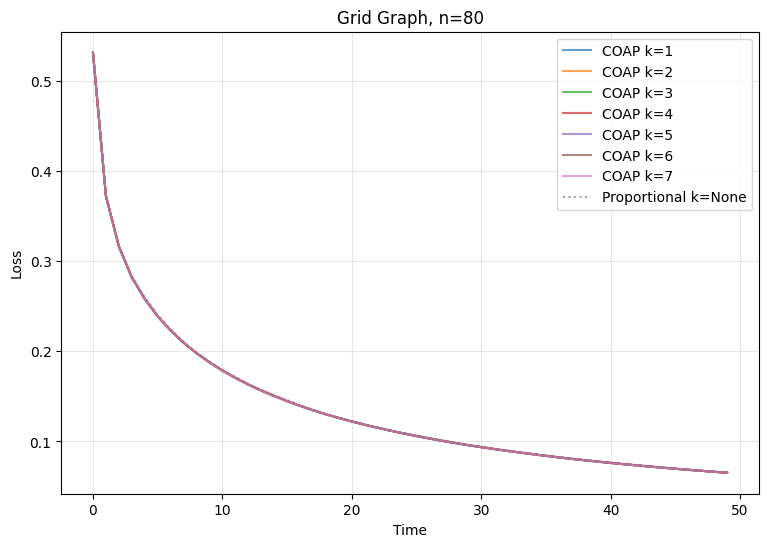

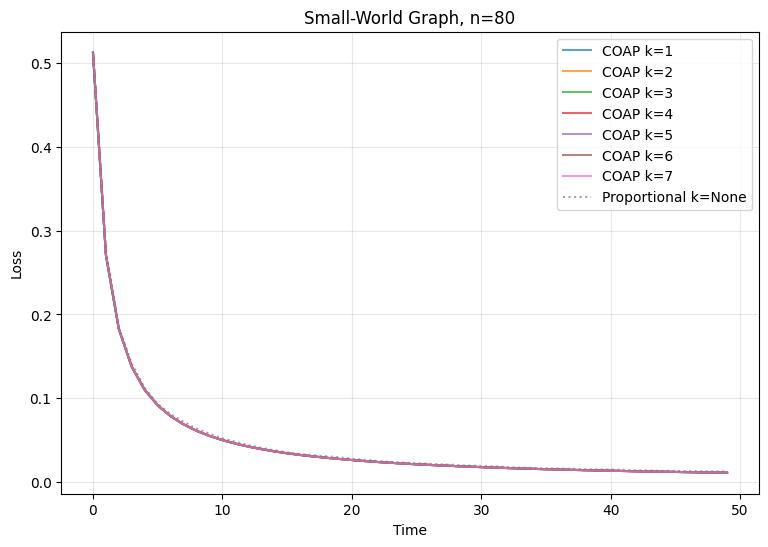

In [5]:
window = (0, min(simulation_duration, 50))
# window = (0, 25)
time_steps = np.arange(window[0], window[1])
benchmarks = ["Optimal", "Proportional"]

k_mask = [
    # 1,
    # 2,
    # 3,
    # 4,
    # 5
]
agent_mask = [
    # "Optimal"
]

def filter(array):
    mutated = np.array(array)
    mean = np.mean(mutated[mutated <= 1.0])
    mutated[mutated > 1.0] = None
    n_fixed = array[array > 1.0].size
    if n_fixed > 0:
        print(f"removed {n_fixed} values")
    return mutated

for graph_type in markets.keys():
    plt.figure(figsize=(9, 6))
    axis = plt.gca()
    # axis.set_ylim(0.0, 1.0)

    for entry in markets[graph_type]:
        if entry["k"] in k_mask or entry["agent_strategy"] in agent_mask:
            continue
        data = entry["simulation_result"][window[0]:window[1]]
        # data = filter(data)
        # avg_ratio_prct = int(entry['avg_market_ratio']*100) if entry['avg_market_ratio'] is not None else 0
        # max_ratio_prct = int(entry['max_market_ratio']*100) if entry['avg_market_ratio'] is not None else 0
        plt.plot(
            time_steps,
            data,
            # label=f"{entry['agent_strategy']} k={entry['k']}, avg_ratio={avg_ratio_prct}% max={max_ratio_prct}%",
            label=f"{entry['agent_strategy']} k={entry['k']}",
            alpha=0.7,
            linestyle="-" if entry['agent_strategy'] not in benchmarks else ":",
        )
        # plt.axhline(y=np.sum(entry["utility_vector"]), color='red', linestyle='--', linewidth=2, label='Optimal utility')
        # plt.axhline(y=np.mean(entry["simulation_result"]), color='blue', linestyle='--', linewidth=2, label='Avg utility')
    plt.xlabel("Time")
    plt.ylabel("Loss")
    plt.title(f"{graph_type} Graph, n={market_size}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()